In [32]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score ,precision_score, confusion_matrix , classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## Load & Split Dataset

In [33]:
data = load_breast_cancer()
X = data.data
y = data.target
print("Dataset loaded successfully!")
print(f"Number of samples: {X.shape[0]}, Number of features: {X.shape[1]}")
print(data.target_names)

Dataset loaded successfully!
Number of samples: 569, Number of features: 30
['malignant' 'benign']


0 = malignant (خبيث)  
1 = benign    (حميد)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples, Testing set: {X_test.shape[0]} samples")

Training set: 455 samples, Testing set: 114 samples


## Models Trainig & Evaluation

Note before evaluation (why I changed pos_label=0)

In the dataset:
- 0 = Malignant (cancer)
- 1 = Benign (not cancer)

By default, scikit-learn calculates Precision / Recall / F1 using class 1 as the “positive” class.  
But in medical problems, the most important goal is to detect malignant cases and avoid missing cancer.

So, I calculated the metrics with:
pos_label = 0

This way, Recall shows how well the model finds malignant tumors (cancer detection rate).

---

Confusion Matrix format in scikit-learn

scikit-learn returns the confusion matrix like this:

With my labels (0 = Malignant, 1 = Benign):

- TN (0,0): Malignant predicted as Malignant  
- FP (0,1): Malignant predicted as Benign  (missed cancer most critical error)
- FN (1,0): Benign predicted as Malignant  (false alarm)
- TP (1,1): Benign predicted as Benign   

### Logistic Regression

- Default (baseline): I trained Logistic Regression with default settings first as a baseline.
- My test (max_iter=1000): I also tested max_iter=1000 to make sure the optimizer fully converges and the results are stable .


In [35]:
LR_Model=LogisticRegression() #default parameters 
LR_model=LogisticRegression(max_iter=1000) #increasing max_iter to ensure convergence

LR_Model.fit(X_train, y_train)
LR_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred = LR_Model.predict(X_test)
y_pred2 = LR_model.predict(X_test)

LR_acc=  accuracy_score(y_test, y_pred)
LR_acc2=  accuracy_score(y_test, y_pred2)

LR_recall = recall_score(y_test, y_pred, pos_label=0)
LR_recall2 = recall_score(y_test, y_pred2, pos_label=0)

LR_f1 = f1_score(y_test, y_pred, pos_label=0)   
LR_f1_2 = f1_score(y_test, y_pred2, pos_label=0)

LR_precision = precision_score(y_test, y_pred, pos_label=0)
LR_precision2 = precision_score(y_test, y_pred2, pos_label=0)

LR_conf_matrix = confusion_matrix(y_test, y_pred )
LR_conf_matrix2 = confusion_matrix(y_test, y_pred2)

class_report = classification_report(y_test, y_pred)
class_report2 = classification_report(y_test, y_pred2)

print(f"Logistic Regression — Accuracy: {LR_acc:.2f} | Recall: {LR_recall:.2f} | F1: {LR_f1:.2f} | Precision: {LR_precision:.2f}")
print("Confusion Matrix:")
print(LR_conf_matrix)
print("Classification Report:")
print(class_report)
print("-" * 100)
print(f"Logistic Regression (max_iter=1000) — Accuracy: {LR_acc2:.2f} | Recall: {LR_recall2:.2f} | F1: {LR_f1_2:.2f} | Precision: {LR_precision2:.2f}")
print("Confusion Matrix:")
print(LR_conf_matrix2)
print("Classification Report:")
print(class_report2)


Logistic Regression — Accuracy: 0.96 | Recall: 0.93 | F1: 0.94 | Precision: 0.95
Confusion Matrix:
[[39  3]
 [ 2 70]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

----------------------------------------------------------------------------------------------------
Logistic Regression (max_iter=1000) — Accuracy: 0.97 | Recall: 0.95 | F1: 0.96 | Precision: 0.98
Confusion Matrix:
[[40  2]
 [ 1 71]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
we

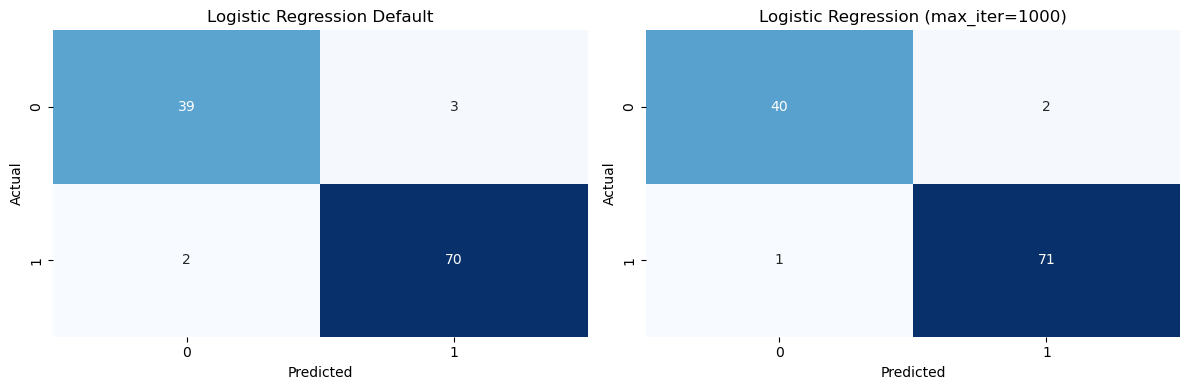

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Logistic Regression Default")
sns.heatmap(LR_conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
plt.title("Logistic Regression (max_iter=1000)")
sns.heatmap(LR_conf_matrix2, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.tight_layout()
plt.show()

### Support Vector Machines (SVM)

- Default :I trained SVC() with default settings first to get a baseline result.
- My test (C=15): I then tested C=15 to see the effect of changing regularization strength (higher C = less regularization) on performance.


In [37]:
SVM_Model=SVC() #default C=1
SVM_model=SVC(C=15) #increasing C to reduce regularization and potentially improve performance on this dataset

SVM_Model.fit(X_train, y_train)
SVM_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",15
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
y_pred = SVM_Model.predict(X_test)
y_pred2 = SVM_model.predict(X_test)

SVM_acc=  accuracy_score(y_test, y_pred )
SVM_acc2=  accuracy_score(y_test, y_pred2)

SVM_recall = recall_score(y_test, y_pred , pos_label=0)   
SVM_recall2 = recall_score(y_test, y_pred2 , pos_label=0)

SVM_f1 = f1_score(y_test, y_pred, pos_label=0)
SVM_f1_2 = f1_score(y_test, y_pred2, pos_label=0)

SVM_precision = precision_score(y_test, y_pred, pos_label=0)
SVM_precision2 = precision_score(y_test, y_pred2, pos_label=0)

SVM_conf_matrix = confusion_matrix(y_test, y_pred)
SVM_conf_matrix2 = confusion_matrix(y_test, y_pred2)

class_report = classification_report(y_test, y_pred)
class_report2 = classification_report(y_test, y_pred2)

print(f"SVM — Accuracy: {SVM_acc:.2f} | Recall: {SVM_recall:.2f} | F1: {SVM_f1:.2f} | Precision: {SVM_precision:.2f}")
print("Confusion Matrix:")
print(SVM_conf_matrix)
print("Classification Report:")
print(class_report)
print("-" * 100)
print(f"SVM (C=15) — Accuracy: {SVM_acc2:.2f} | Recall: {SVM_recall2:.2f} | F1: {SVM_f1_2:.2f} | Precision: {SVM_precision2:.2f}")
print("Confusion Matrix:")
print(SVM_conf_matrix2)
print("Classification Report:")
print(class_report2)

SVM — Accuracy: 0.93 | Recall: 0.86 | F1: 0.90 | Precision: 0.95
Confusion Matrix:
[[36  6]
 [ 2 70]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        42
           1       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114

----------------------------------------------------------------------------------------------------
SVM (C=15) — Accuracy: 0.94 | Recall: 0.88 | F1: 0.91 | Precision: 0.95
Confusion Matrix:
[[37  5]
 [ 2 70]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91        42
           1       0.93      0.97      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94

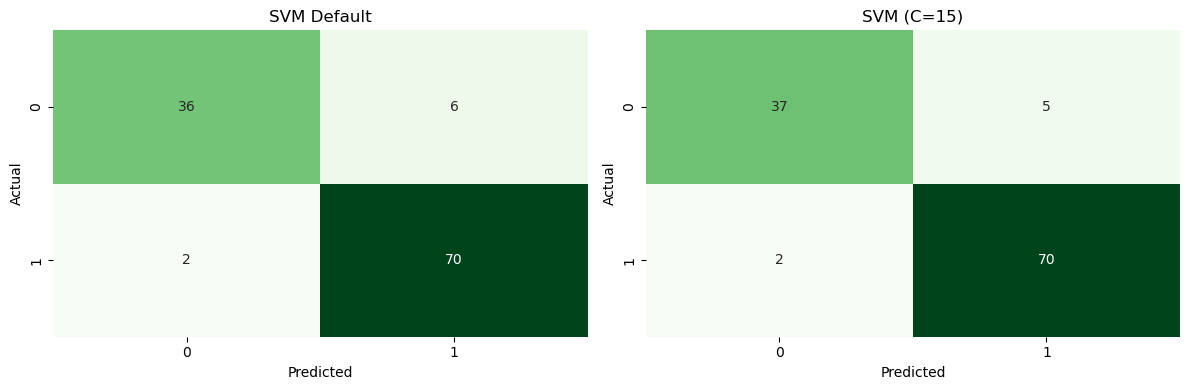

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("SVM Default")
sns.heatmap(SVM_conf_matrix, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
plt.title("SVM (C=15)")
sns.heatmap(SVM_conf_matrix2, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.tight_layout()
plt.show()

### K Nearest Neighbors (KNN)

- Default: I trained KNN with the default n_neighbors=5 as a baseline.
- My test (n_neighbors=10): I also tested n_neighbors=10 to check if using more neighbors gives more stable predictions and improves the results.

In [39]:
KNN_Model=KNeighborsClassifier() #default n_neighbors=5
KNN_model=KNeighborsClassifier(n_neighbors=10) # increasing to see if it improves performance

KNN_Model.fit(X_train, y_train)
KNN_model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
y_pred = KNN_Model.predict(X_test)
y_pred2 = KNN_model.predict(X_test)

KNN_acc=  accuracy_score(y_test, y_pred)
KNN_acc2=  accuracy_score(y_test, y_pred2)

KNN_recall = recall_score(y_test, y_pred , pos_label=0)
KNN_recall2 = recall_score(y_test, y_pred2 , pos_label=0)

KNN_f1 = f1_score(y_test, y_pred, pos_label=0)
KNN_f1_2 = f1_score(y_test, y_pred2, pos_label=0)

KNN_precision = precision_score(y_test, y_pred, pos_label=0)
KNN_precision2 = precision_score(y_test, y_pred2, pos_label=0)

KNN_conf_matrix = confusion_matrix(y_test, y_pred)
KNN_conf_matrix2 = confusion_matrix(y_test, y_pred2)

KNNclassification_report= classification_report(y_test, y_pred)
KNNclassification_report2= classification_report(y_test, y_pred2)

print(f"KNN — Accuracy: {KNN_acc:.2f} | Recall: {KNN_recall:.2f} | F1: {KNN_f1:.2f} | Precision: {KNN_precision:.2f}")
print("Confusion Matrix:")
print(KNN_conf_matrix)
print("Classification Report for KNN (default n_neighbors=5):")
print(KNNclassification_report)
print("-" * 100)
print(f"KNN (n_neighbors=10) — Accuracy: {KNN_acc2:.2f} | Recall: {KNN_recall2:.2f} | F1: {KNN_f1_2:.2f} | Precision: {KNN_precision2:.2f}")
print("Confusion Matrix:")
print(KNN_conf_matrix2)
print("Classification Report for KNN (n_neighbors=10):")
print(KNNclassification_report2)


KNN — Accuracy: 0.91 | Recall: 0.90 | F1: 0.88 | Precision: 0.86
Confusion Matrix:
[[38  4]
 [ 6 66]]
Classification Report for KNN (default n_neighbors=5):
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        42
           1       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114

----------------------------------------------------------------------------------------------------
KNN (n_neighbors=10) — Accuracy: 0.93 | Recall: 0.90 | F1: 0.90 | Precision: 0.90
Confusion Matrix:
[[38  4]
 [ 4 68]]
Classification Report for KNN (n_neighbors=10):
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0

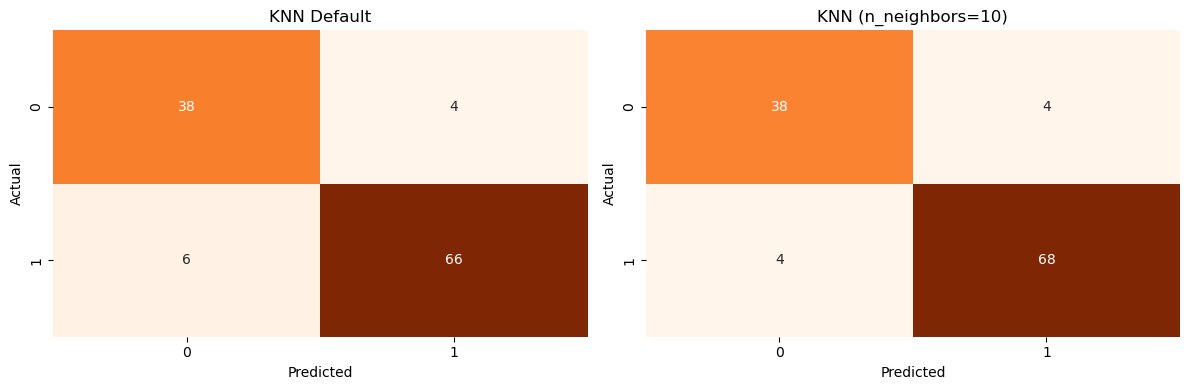

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("KNN Default")
sns.heatmap(KNN_conf_matrix, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
plt.title("KNN (n_neighbors=10)")
sns.heatmap(KNN_conf_matrix2, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Model Comparison



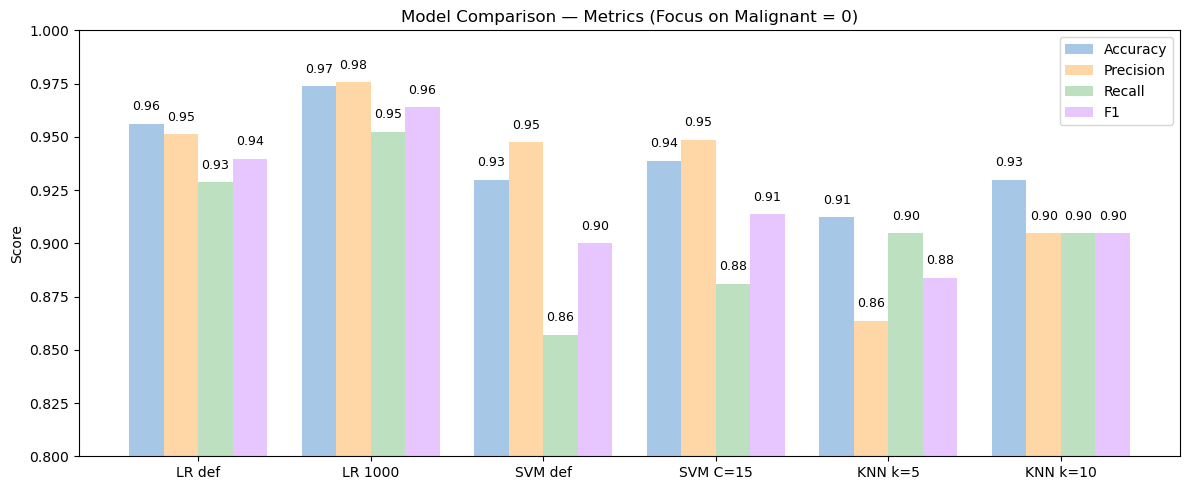

In [ ]:
models = [
    "LR def", "LR 1000",
    "SVM def", "SVM C=15",
    "KNN k=5", "KNN k=10"
]

accuracy  = [LR_acc,LR_acc2, SVM_acc, SVM_acc2, KNN_acc, KNN_acc2]
precision = [LR_precision,LR_precision2, SVM_precision, SVM_precision2, KNN_precision, KNN_precision2]
recall    = [LR_recall, LR_recall2, SVM_recall, SVM_recall2, KNN_recall, KNN_recall2]
f1        = [LR_f1, LR_f1_2, SVM_f1, SVM_f1_2, KNN_f1, KNN_f1_2]

x = np.arange(len(models))
w = 0.2

plt.figure(figsize=(12,5))

bars1 = plt.bar(x - 1.5*w, accuracy,  width=w, label="Accuracy",      color="#A7C7E7")  
bars2 = plt.bar(x - 0.5*w, precision, width=w, label="Precision", color="#FFD6A5")  
bars3 = plt.bar(x + 0.5*w, recall,    width=w, label="Recall",    color="#BDE0C1") 
bars4 = plt.bar(x + 1.5*w, f1,        width=w, label="F1",        color="#E7C6FF")  

plt.ylim(0.8, 1.0)
plt.ylabel("Score")
plt.title("Model Comparison — Metrics (Focus on Malignant = 0)")
plt.xticks(x, models, rotation=0)
plt.legend()

def add_labels(bar_container):
    for bar in bar_container:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.005,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.tight_layout()
plt.show()

### Comparison Table (main focus: Recall for Malignant = 0)

In this task, Malignant (label 0) is the most important class.  
So I report **Precision / Recall / F1 for class 0**, because **Recall(0)** tells me how well the model detects cancer .  
In the confusion matrix `[[TN, FP], [FN, TP]]`, **FP (0,1)** means *malignant predicted as benign* (**missed cancer**).

| Model | Accuracy | Precision  | **Recall** | F1  | Confusion Matrix| Missed Cancers (FP) |
|---|---:|---:|---:|---:|---|---:|
| Logistic Regression (default) | 0.96 | 0.95 | 0.93 | 0.94 | [[39, 3],    [2, 70]] | 3 |
| **Logistic Regression (max_iter=1000)** | **0.97** | **0.98** | **0.95** | **0.96** | [[40, 2], [ 1, 71]] | **2** |
| SVM (default) | 0.93 | 0.95 | 0.86 | 0.90 | [[36, 6],    [2, 70]] | 6 |
| SVM (C=15) | 0.94 | 0.95 | 0.88 | 0.91 | [[37, 5],    [2, 70]] | 5 |
| KNN (default, k=5) | 0.91 | 0.86 | 0.90 | 0.88 | [[38, 4],    [6, 66]] | 4 |
| KNN (k=10) | 0.93 | 0.90 | 0.90 | 0.90 | [[38, 4],    [4, 68]] | 4 |

---

### Conclusion (medical focus)

- **Best model (based on Recall for malignant):**  
  **Logistic Regression (max_iter=1000)** performed best because it achieved the highest **Recall for Malignant (0.95)**, meaning it detected the largest number of cancer cases.  
  It also had the lowest number of **missed cancers** (**FP = 2**), which is the most critical error to avoid.

- **Most important metric in a medical context:**  
  **Recall for Malignant** is the most important metric because missing a malignant tumor (predicting it as benign) can delay diagnosis and treatment.  
  That is why I prioritized **maximizing Recall(0)** and also checked **FP** in the confusion matrix (missed cancer cases).